In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv("../data/processed/cleaned_orders.csv", parse_dates=["Order_Date", "Ship_Date"])
df.head()

,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Postal_Code,Region,Product_ID,Category,Sub-Category,Product_Name,Sales
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


## Section A: Top Customers by Sales

- Which customer has generated the highest sales?
- Who are the top 10 customers?

In [3]:
# Calculate total sales for each customer and select the top 10 customers
top_customers = (
    df.groupby("Customer_Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(f"Top customer name: {top_customers.idxmax()}")

Top customer name: Sean Miller


Best one is: Sean Miller


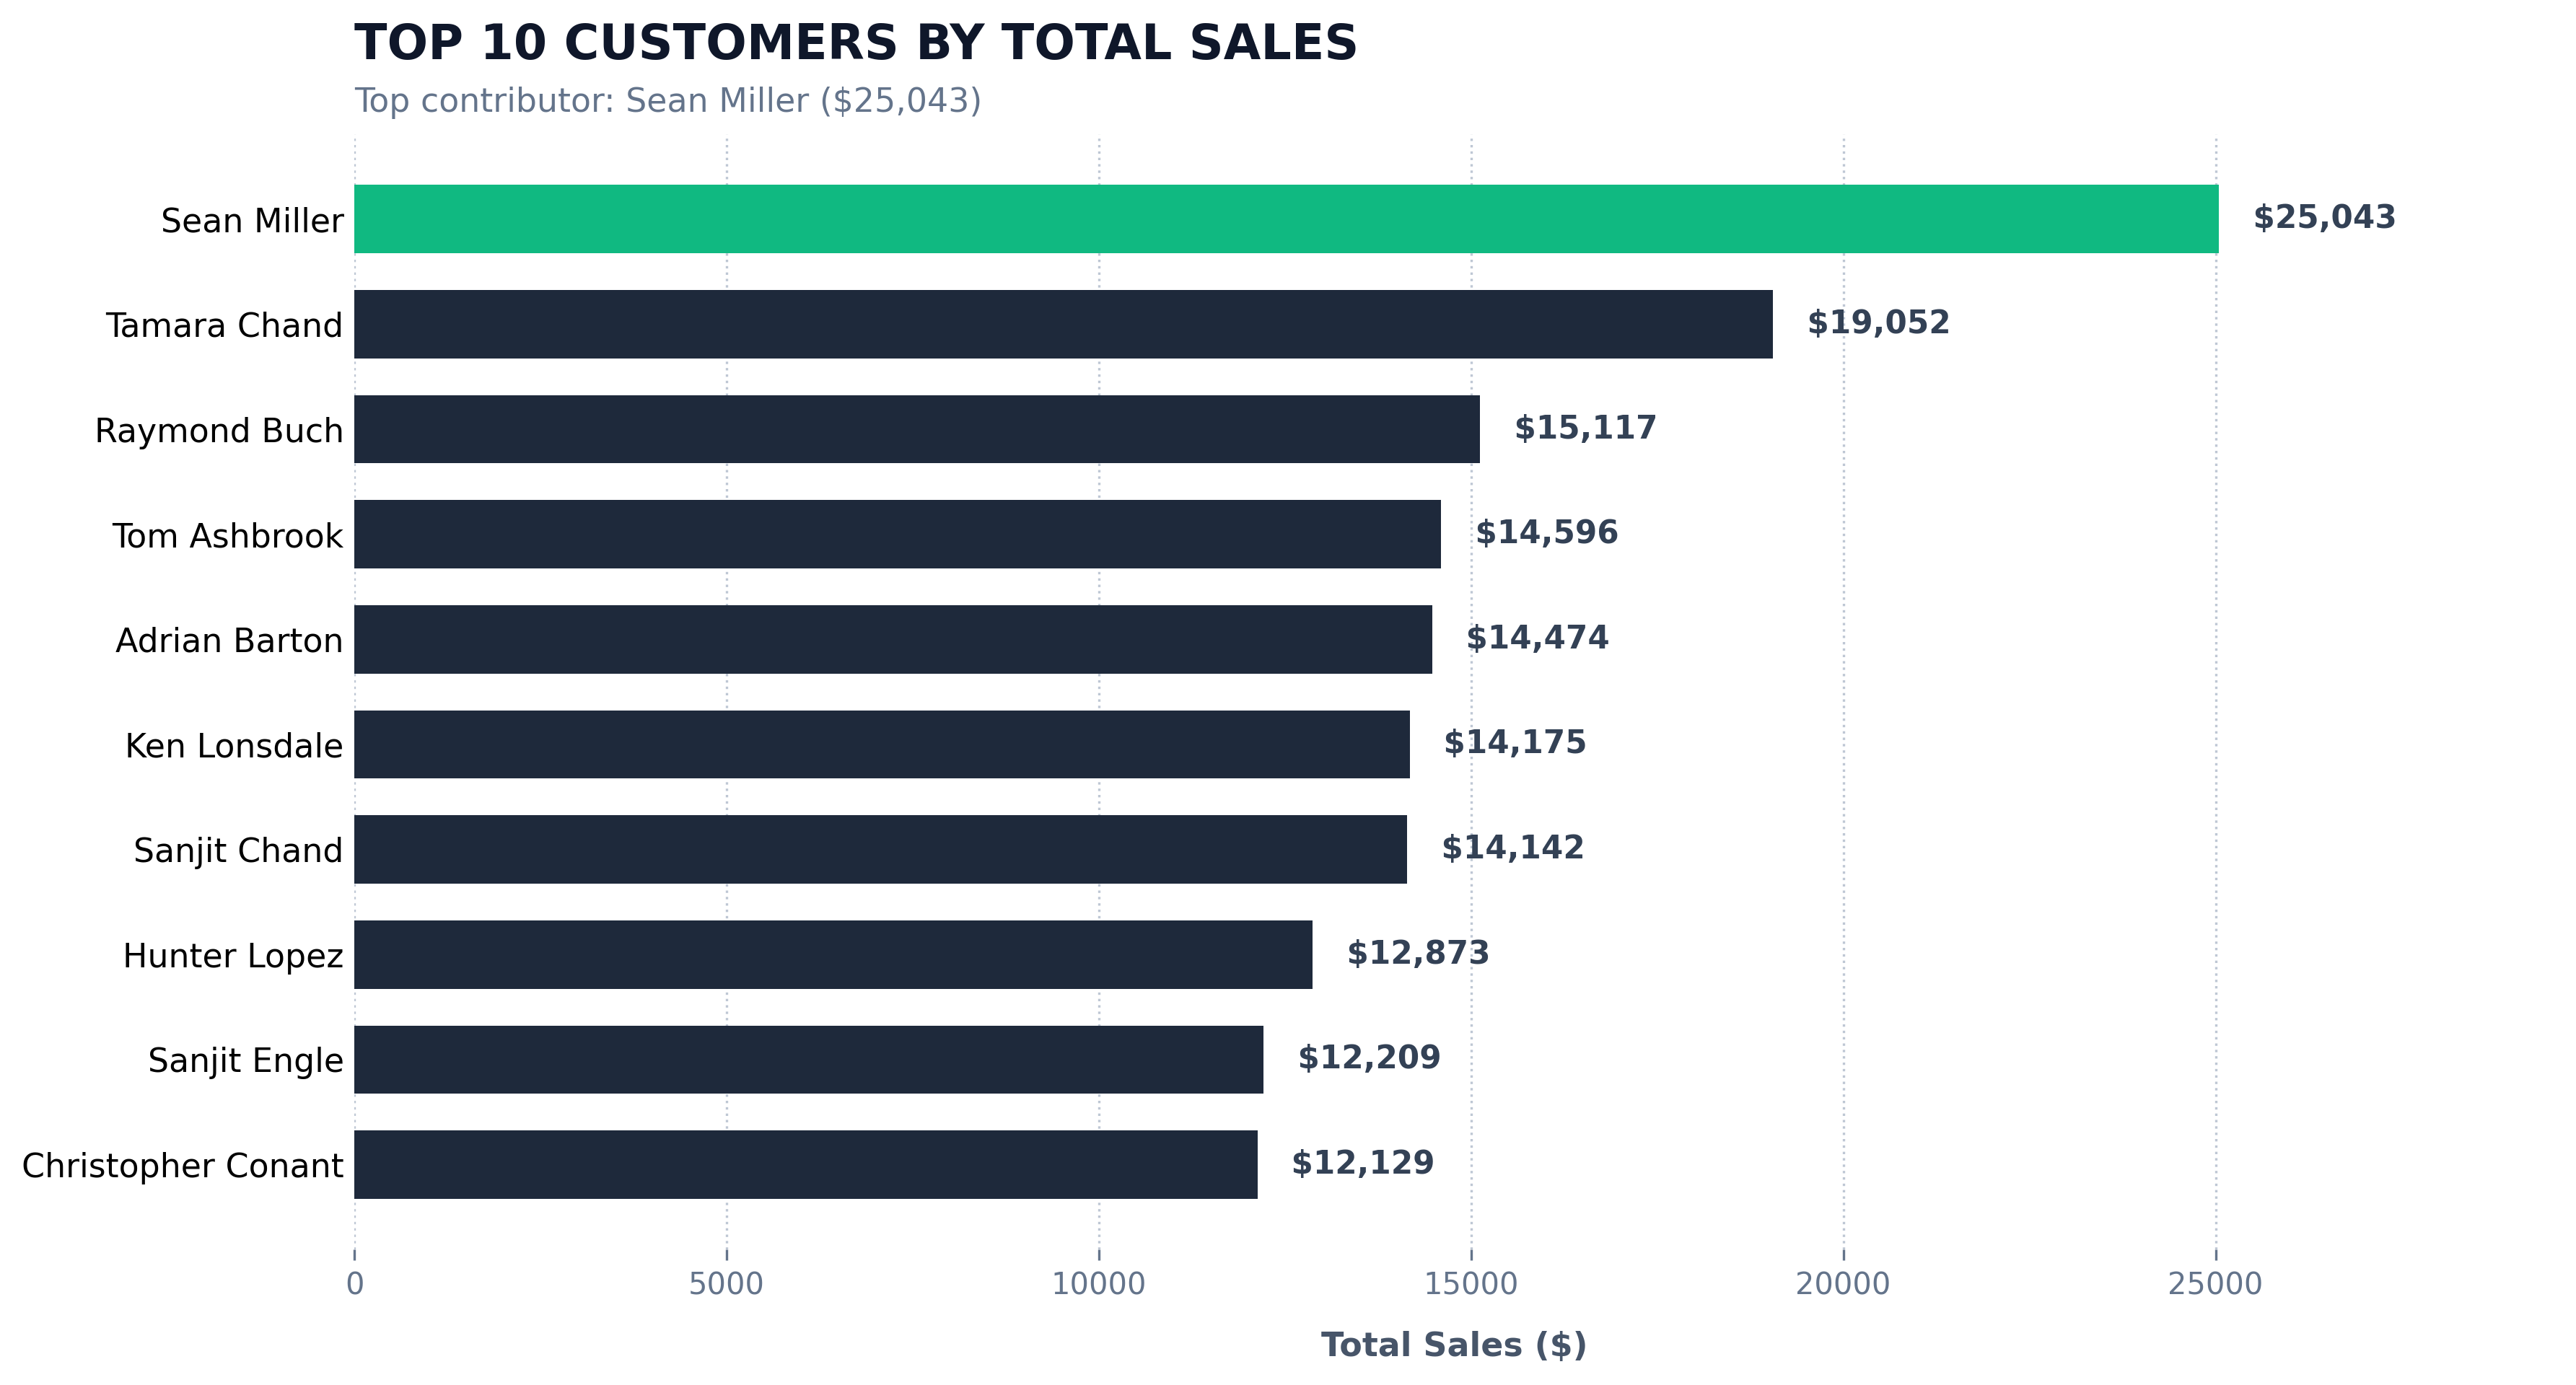

In [4]:
# 1. Data Preparation
top_customers = (
    df.groupby("Customer_Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .sort_values()  # Sort in ascending order for the horizontal bar chart
)

best_customer = top_customers.idxmax()
print(f"Best one is: {best_customer}")

# 2. Dynamic Colors: Use slate blue for all customers and vibrant emerald green for the #1 customer
colors = ["#1E293B" if name != best_customer else "#10B981" for name in top_customers.index]

# 3. Figure & Axis Setup
fig, ax = plt.subplots(figsize=(12, 6.5), dpi=300)

# Plot the bars
bars = ax.barh(
    top_customers.index, 
    top_customers.values, 
    color=colors, 
    height=0.65, 
    edgecolor="none"
)

# 4. Data Value Labels ($ inside/next to bars)
ax.bar_label(
    bars, 
    labels=[f"  ${x:,.0f}" for x in top_customers], 
    padding=4, 
    fontsize=10.5, 
    fontweight="bold", 
    color="#334155"
)

# 5. Titles & Subtitles
plt.title("TOP 10 CUSTOMERS BY TOTAL SALES", fontsize=16, fontweight="bold", pad=25, loc="left", color="#0F172A")
ax.text(0, 1.02, f"Top contributor: {best_customer} (${top_customers.max():,.0f})", 
        transform=ax.transAxes, fontsize=11, color="#64748B", fontweight="medium")

# 6. Styling & Grid Cleanup
ax.set_xlabel("Total Sales ($)", fontsize=11, fontweight="bold", labelpad=10, color="#475569")
ax.grid(axis="x", linestyle=":", alpha=0.6, color="#94A3B8")
ax.set_axisbelow(True)  # Keep gridlines behind the bars

# Remove unnecessary spines for a clean frame look
for spine in ["top", "right", "bottom", "left"]:
    ax.spines[spine].set_visible(False)

# X-axis Limit (To prevent text labels from being cut off)
ax.set_xlim(0, top_customers.max() * 1.18)

# Y-axis Labels Font Size & Weight
ax.tick_params(axis="y", labelsize=11, length=0)
ax.tick_params(axis="x", labelsize=10, colors="#64748B")

plt.tight_layout()

# 7. High Resolution Export
plt.savefig(
    "../reports/charts/top10_customers.png", 
    dpi=300, 
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

In [5]:
# Calculate the top customer's share of total sales
top1_customer_sales = top_customers.iloc[0]
top1_share = (top1_customer_sales / df["Sales"].sum()) * 100
print(f"Top customer contributes {top1_share:.2f}% of total sales")

Top customer contributes 0.54% of total sales


## Section B: Customer Segment Analysis
- Which customer segments generate the most sales?

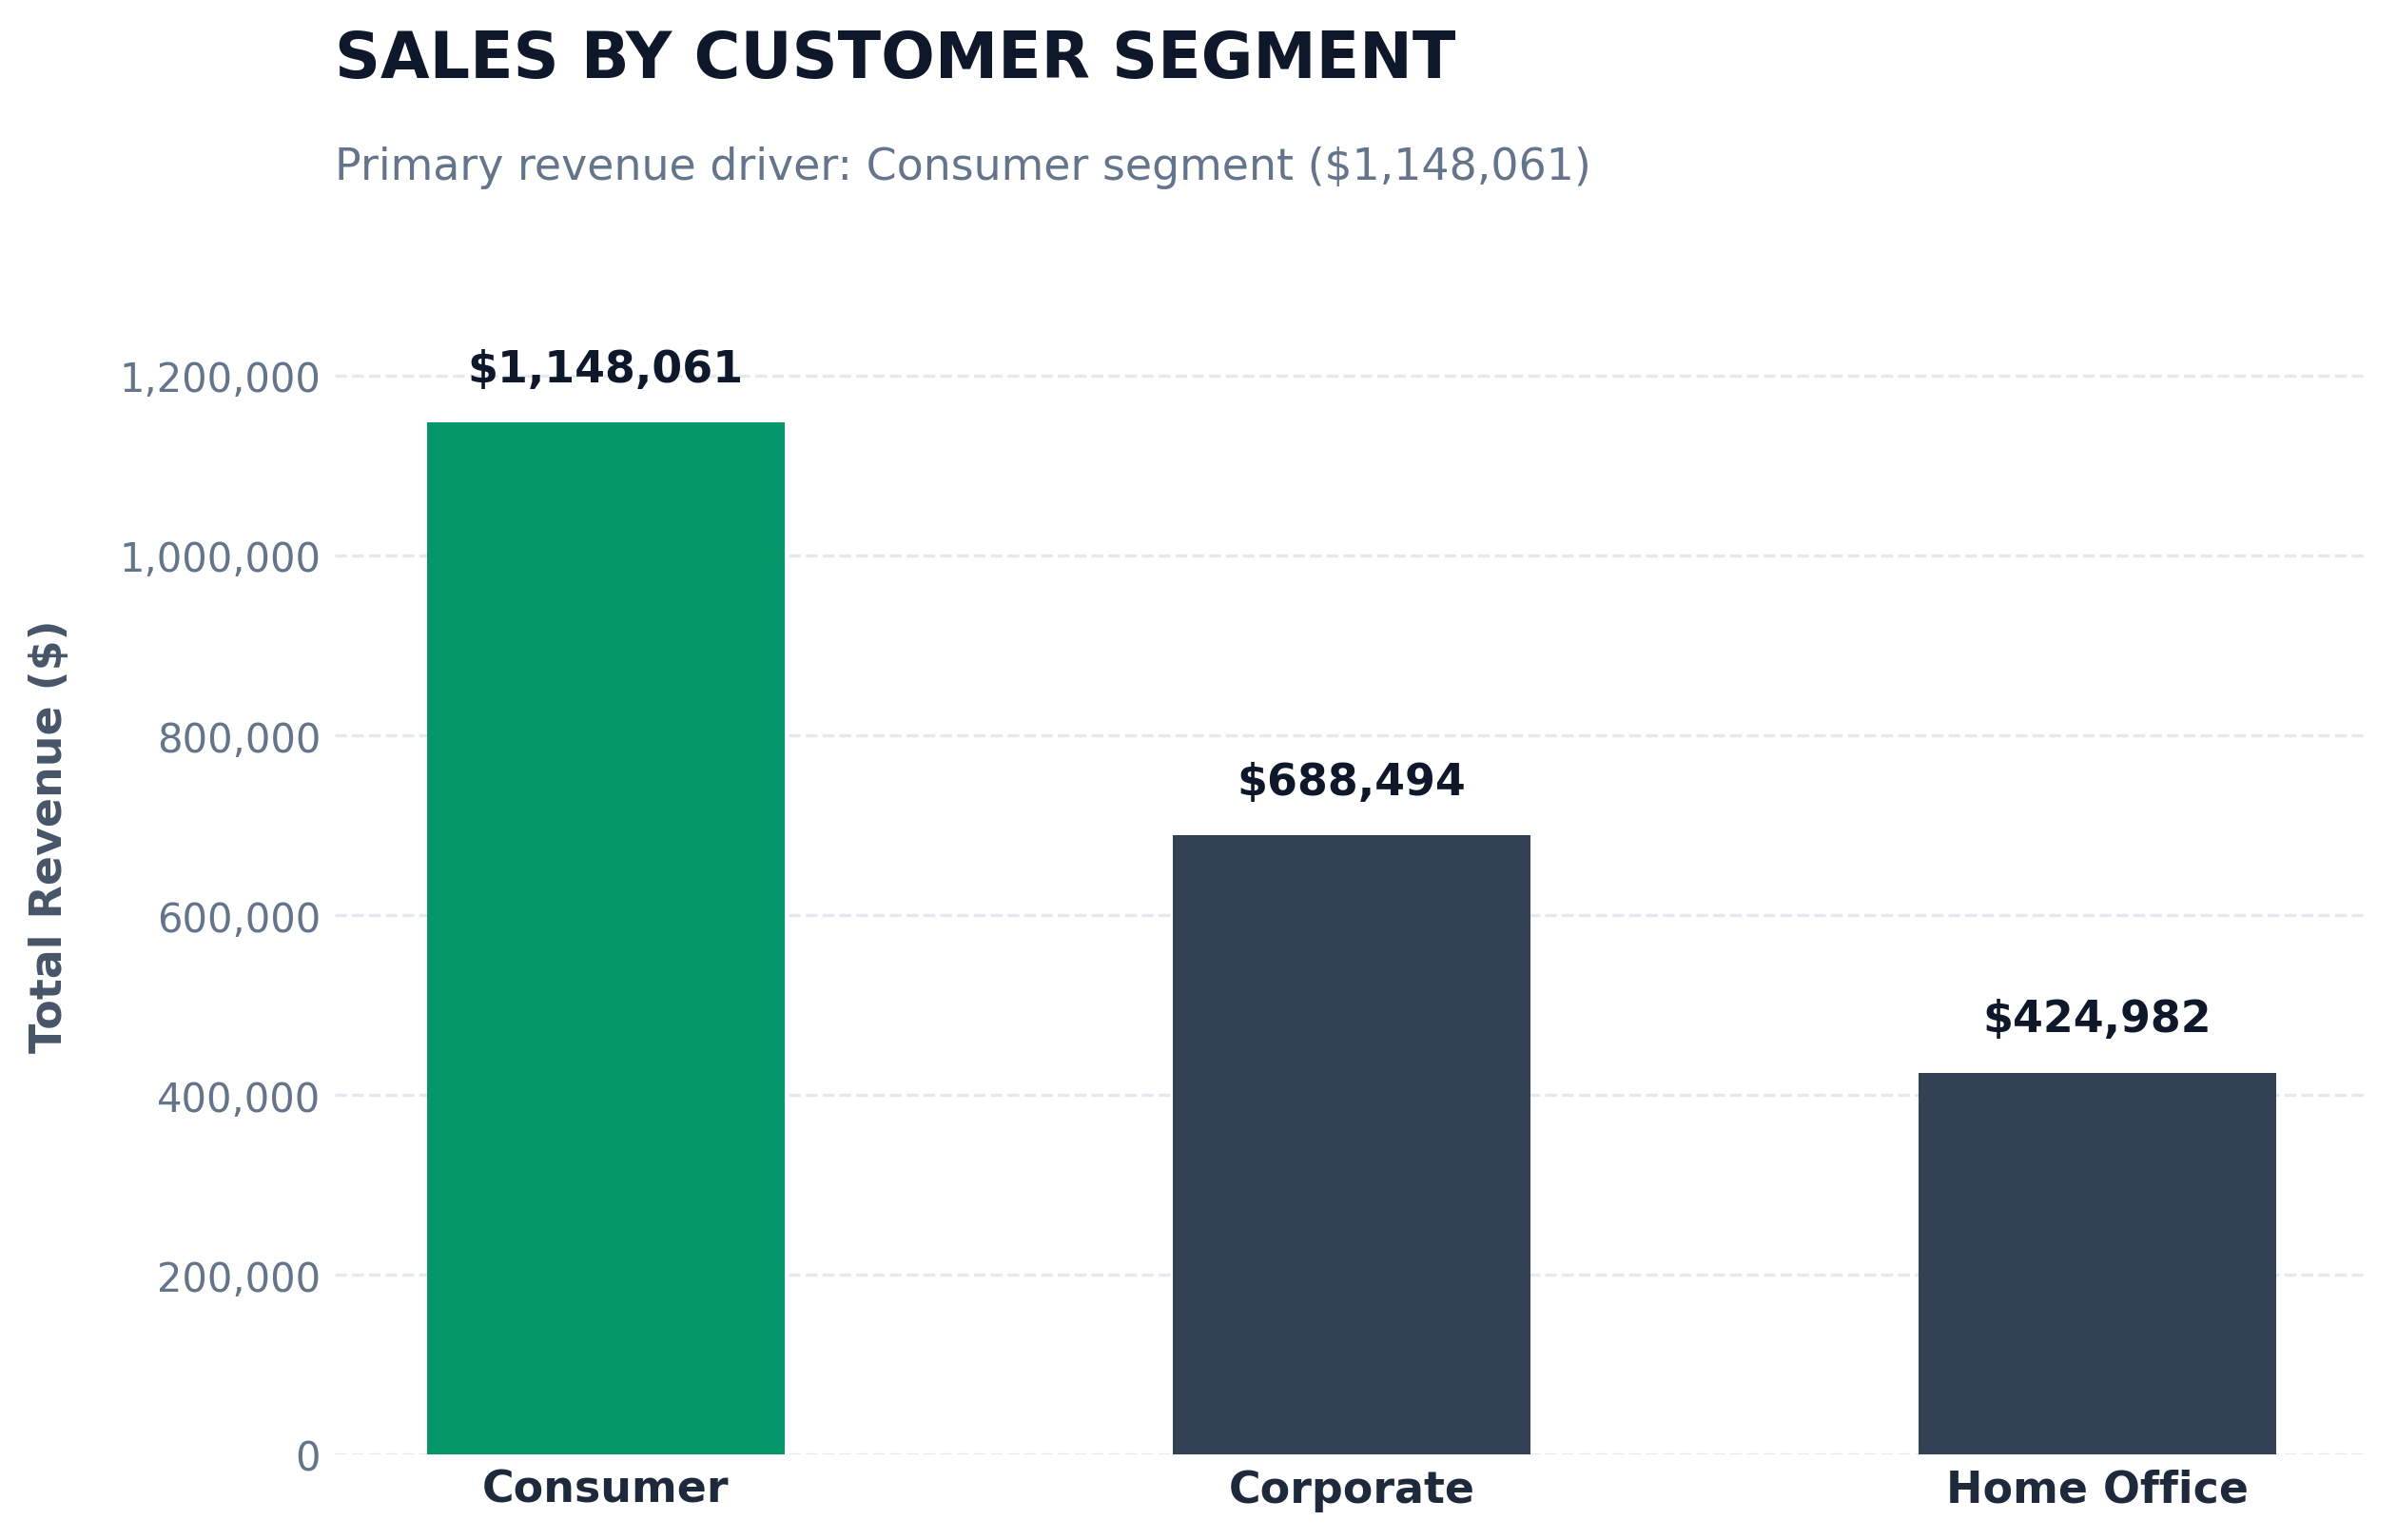

In [6]:
from matplotlib.ticker import StrMethodFormatter

# 1. Data Aggregation
segment_sales = (
    df.groupby("Segment")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

best_segment = segment_sales.idxmax()

# 2. Dynamic Palette
colors = ["#059669" if seg == best_segment else "#334155" for seg in segment_sales.index]

# 3. Figure & Axis Setup
fig, ax = plt.subplots(figsize=(8.5, 5.5), dpi=300)

bars = ax.bar(
    segment_sales.index,
    segment_sales.values,
    color=colors,
    width=0.48,
    edgecolor="none"
)

# 4. Value Labels ($ Top of Bars)
ax.bar_label(
    bars,
    labels=[f"${x:,.0f}" for x in segment_sales],
    padding=8,
    fontsize=11,
    fontweight="bold",
    color="#0F172A"
)

# -------------------------------------------------------------
# FIX FOR 1e6 OVERLAP: Turn off scientific notation / offset
# -------------------------------------------------------------
ax.ticklabel_format(style='plain', axis='y')
# (Optional) Format Y-axis values with commas
ax.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))

# 5. Executive Header & Subtitle
plt.title(
    "SALES BY CUSTOMER SEGMENT", 
    fontsize=16, 
    fontweight="bold", 
    pad=35,               # Increase padding for better separation
    loc="left", 
    color="#0F172A"
)
ax.text(
    0, 1.03, 
    f"Primary revenue driver: {best_segment} segment (${segment_sales.max():,.0f})", 
    transform=ax.transAxes, 
    fontsize=11, 
    color="#64748B", 
    fontweight="medium"
)

# 6. Grid, Spines & Clean Axes
ax.set_ylabel("Total Revenue ($)", fontsize=11, fontweight="bold", labelpad=12, color="#475569")
ax.grid(axis="y", linestyle="--", alpha=0.5, color="#CBD5E1")
ax.set_axisbelow(True)

# Hide Outer Border Lines
for spine in ["top", "right", "left", "bottom"]:
    ax.spines[spine].set_visible(False)

# Y-Axis Range Fix
ax.set_ylim(0, segment_sales.max() * 1.20)

# Ticks Styling
ax.tick_params(axis="y", labelsize=10, colors="#64748B", length=0)
ax.tick_params(axis="x", labelsize=11, length=0)
plt.xticks(rotation=0, fontweight="bold", color="#1E293B")

plt.tight_layout()

# 7. High-Res Save
plt.savefig(
    "../reports/charts/segment_sales.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

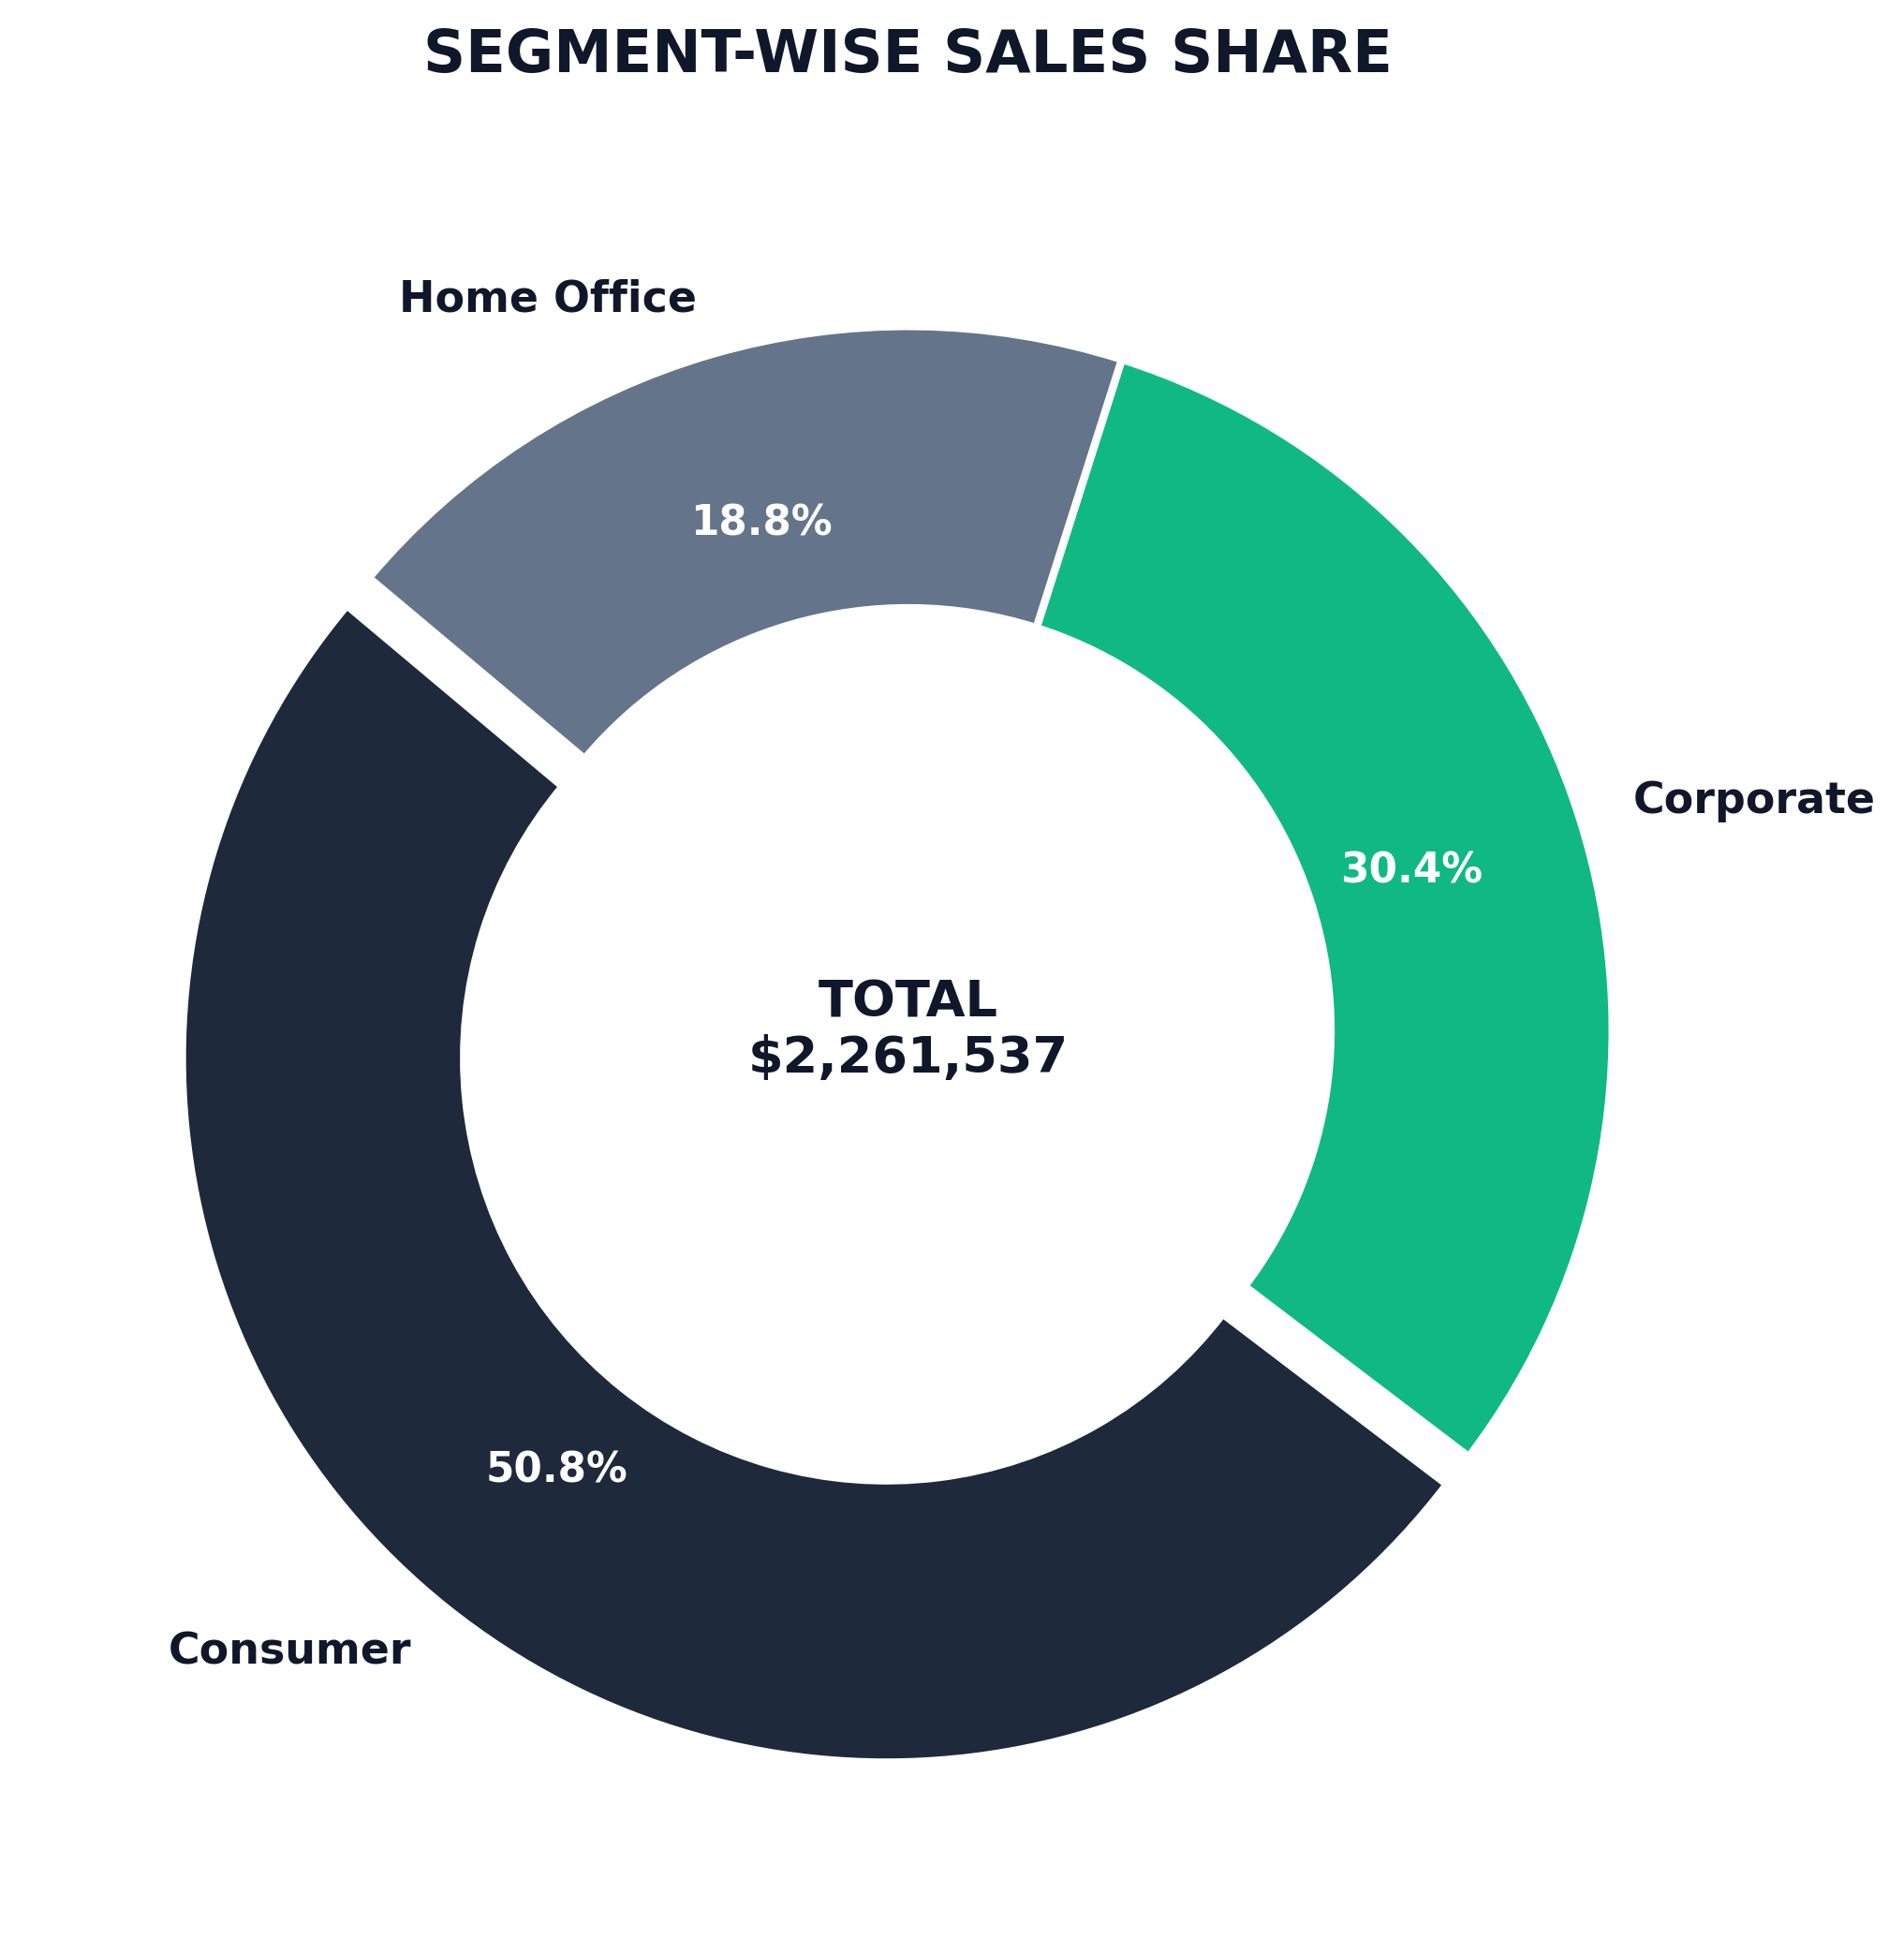

In [7]:
# 1. Data Aggregation & Sorting
segment_sales = df.groupby("Segment")["Sales"].sum().sort_values(ascending=False)
total_sales = segment_sales.sum()

# 2. Modern Color Palette (Slate Navy, Emerald, Soft Blue)
colors = ["#1E293B", "#10B981", "#64748B", "#38BDF8", "#F59E0B"][:len(segment_sales)]

# Highlight the highest segment by slightly separating it from the rest of the chart
explode = [0.05 if i == 0 else 0 for i in range(len(segment_sales))]

# 3. Figure Setup
fig, ax = plt.subplots(figsize=(7, 7), dpi=300)

# 4. Plot Pie/Donut Chart
wedges, texts, autotexts = ax.pie(
    segment_sales,
    labels=segment_sales.index,
    autopct="%1.1f%%",
    startangle=140,
    colors=colors,
    explode=explode,
    pctdistance=0.75,
    labeldistance=1.08,
    wedgeprops=dict(width=0.4, edgecolor="white", linewidth=2)  # Donut Ring Effect
)

# 5. Styling Percentages & Labels Text
for autotext in autotexts:
    autotext.set_color("white")
    autotext.set_fontsize(10.5)
    autotext.set_fontweight("bold")

for text in texts:
    text.set_color("#0F172A")
    text.set_fontsize(11)
    text.set_fontweight("bold")

# 6. Center Text (Total Sales Summary inside Donut Hole)
ax.text(
    0, 0, 
    f"TOTAL\n${total_sales:,.0f}", 
    ha="center", va="center", 
    fontsize=13, fontweight="bold", 
    color="#0F172A"
)

# 7. Modern Header & Subtitle
plt.title("SEGMENT-WISE SALES SHARE", fontsize=15, fontweight="bold", pad=20, loc="center", color="#0F172A")

plt.tight_layout()

# 8. High Resolution Save
plt.savefig(
    "../reports/charts/segment_share_pie.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

## Section C: Repeat Customers Analysis
- Are some customers placing orders repeatedly?

In [8]:
# Calculate the number of unique orders placed by each customer
customer_order_counts = df.groupby("Customer_Name")["Order_ID"].nunique().sort_values(ascending=False)

print(customer_order_counts.head(10))

Customer_Name
Emily Phan             17
Zuschuss Carroll       13
Chloris Kastensmidt    13
Joel Eaton             13
Patrick Gardner        13
Rick Bensley           12
Sally Hughsby          12
Pete Kriz              12
Noel Staavos           12
Resi Pölking           12
Name: Order_ID, dtype: int64


In [9]:
# Count the number of unique orders for each customer
order_counts = df.groupby('Customer_Name')['Order_ID'].nunique()

# Filter customers who placed more than one order
repeat_customers = order_counts[order_counts > 1]

print(f"Total Repeat Customers: {len(repeat_customers)}")

Total Repeat Customers: 780


Repeat Customers: 780
One-time Customers: 13


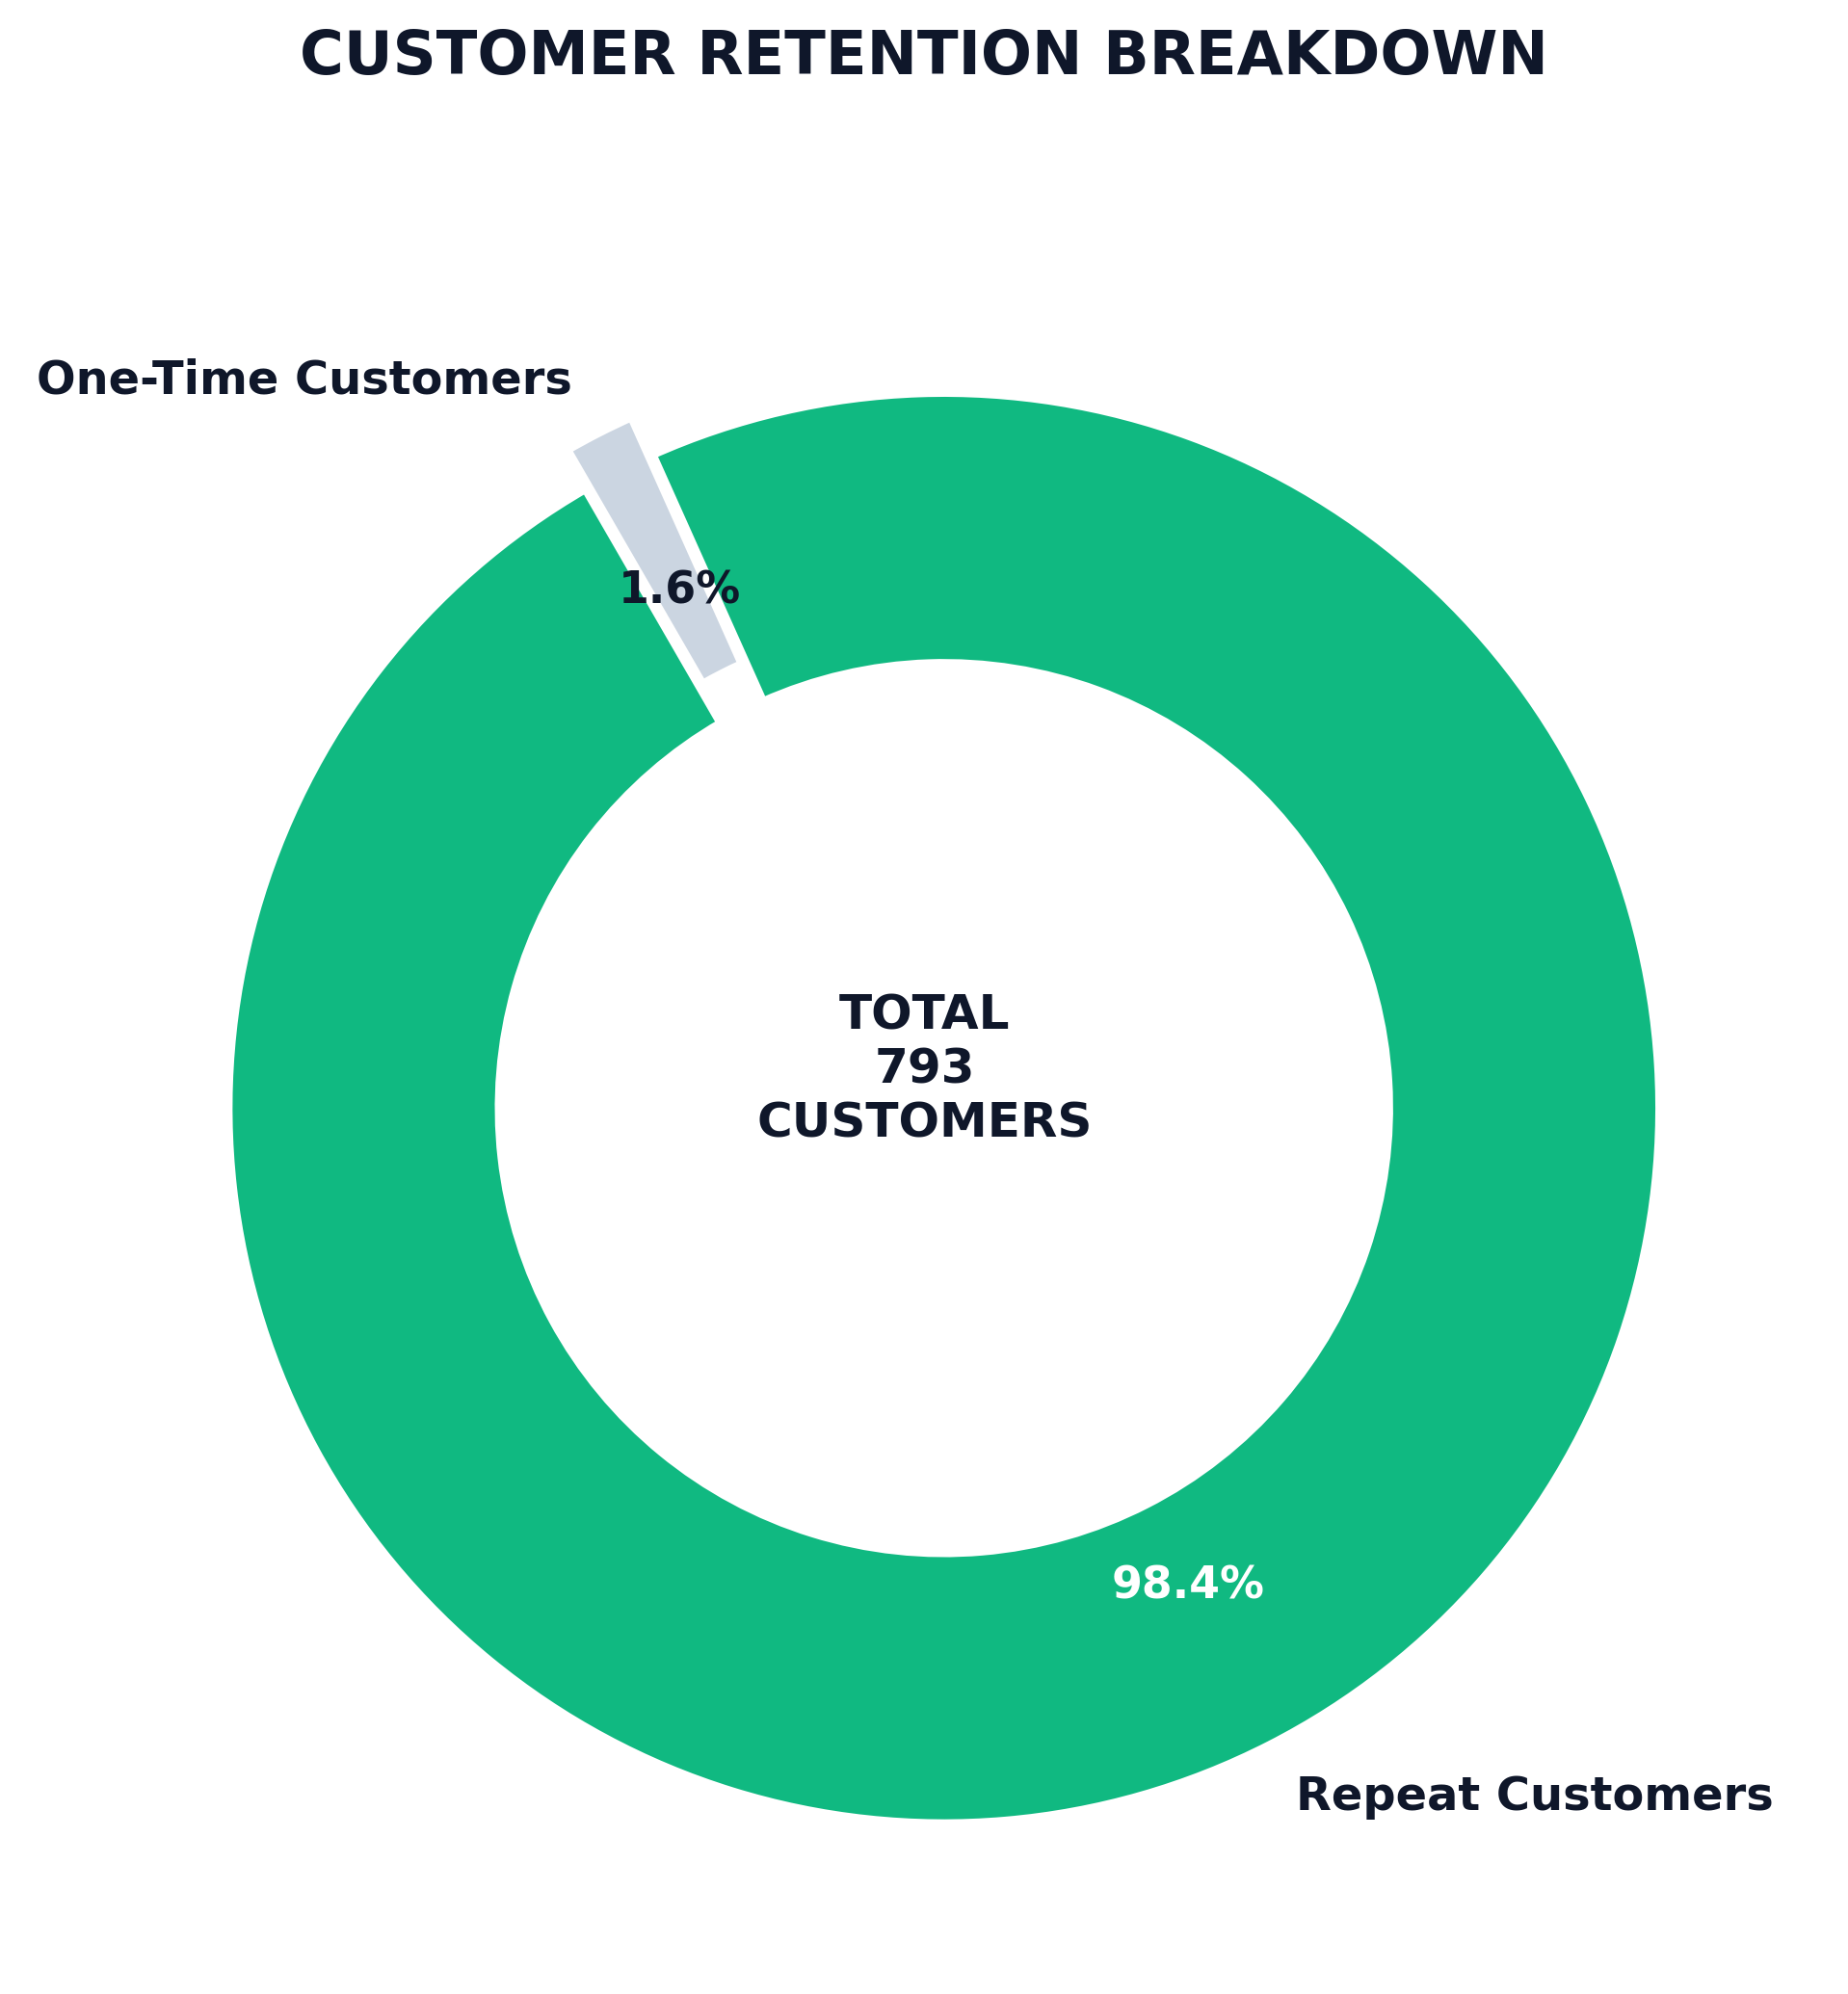

In [10]:
# 1. Calculation
customer_order_counts = df.groupby("Customer_ID")["Order_ID"].nunique()

repeat_customers = (customer_order_counts > 1).sum()
one_time_customers = (customer_order_counts == 1).sum()
total_customers = repeat_customers + one_time_customers

print(f"Repeat Customers: {repeat_customers}")
print(f"One-time Customers: {one_time_customers}")

values = [repeat_customers, one_time_customers]
labels = ["Repeat Customers", "One-Time Customers"]

# 2. Executive Color Palette (Vibrant Emerald for Repeat, Soft Slate Gray for One-Time)
colors = ["#10B981", "#CBD5E1"]
explode = [0.06, 0]  # Highlight the repeat customers slice

# 3. Figure & Donut Setup
fig, ax = plt.subplots(figsize=(7, 7), dpi=300)

wedges, texts, autotexts = ax.pie(
    values,
    labels=labels,
    autopct="%1.1f%%",
    startangle=120,
    colors=colors,
    explode=explode,
    pctdistance=0.75,
    labeldistance=1.08,
    wedgeprops=dict(width=0.38, edgecolor="white", linewidth=2.5)  # Modern Donut Ring
)

# 4. Label & Percentage Styling
for autotext in autotexts:
    autotext.set_color("#0F172A" if autotext.get_text() == f"{one_time_customers/total_customers*100:.1f}%" else "white")
    autotext.set_fontsize(11)
    autotext.set_fontweight("bold")

for text in texts:
    text.set_color("#0F172A")
    text.set_fontsize(11.5)
    text.set_fontweight("bold")

# 5. Center Callout (Total Customers Count)
ax.text(
    0, 0, 
    f"TOTAL\n{total_customers:,}\nCUSTOMERS", 
    ha="center", va="center", 
    fontsize=12, fontweight="bold", 
    color="#0F172A"
)

# 6. Header & Subtitle
plt.title("CUSTOMER RETENTION BREAKDOWN", fontsize=15, fontweight="bold", pad=25, loc="center", color="#0F172A")

plt.tight_layout()

# 7. High-Res Save
plt.savefig(
    "../reports/charts/repeat_vs_onetime.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

## Section D: Average Revenue Per User/Customer

In [ ]:
# Calculate total sales and total orders for each customer
avg_order_value = df.groupby("Customer_Name").agg(
    total_sales=("Sales", "sum"),
    total_orders=("Order_ID", "nunique")
)

# Calculate the average order value for each customer
avg_order_value["avg_order_value"] = avg_order_value["total_sales"] / avg_order_value["total_orders"]

# Sort customers by average order value from highest to lowest
avg_order_value = avg_order_value.sort_values("avg_order_value", ascending=False)

print(avg_order_value.head(10))

                      total_sales  total_orders  avg_order_value
Customer_Name                                                   
Sean Miller             25043.050             5      5008.610000
Tamara Chand            19052.218             5      3810.443600
Tom Ashbrook            14595.620             4      3648.905000
Grant Thornton           9351.212             3      3117.070667
Becky Martin            11789.630             4      2947.407500
Mitch Willingham         5253.876             2      2626.938000
Raymond Buch            15117.339             6      2519.556500
Christopher Conant      12129.072             5      2425.814400
Peter Fuller             9062.864             4      2265.716000
Christopher Martinez     8954.020             4      2238.505000


## 👥 Customer Analysis Summary

### Top Customers
- Highest spending customer: `Sean Miller` (contributed 1.11% of total sales)
- Top 10 customers together contribute `6.80% of total revenue`

### Customer Segments
- Best-performing segment: `Consumer` (50.76% of total sales)
- Weakest segment: `Home Office`

### Customer Loyalty
- Repeat customers: `780 (98.36%)`
- One-time customers: `13 (1.64%)`

### 💡 Business Insight

The top customers, including `Sean Miller` , `Tamara Chand`, and `Raymond Buch`,
contribute a significant share of the business's total revenue. However, the
top 10 customers contribute 6.80% of total revenue, indicating a moderate concentration of revenue among high-value customers.

The business should focus retention efforts, such as loyalty programs and
personalized offers, on these high-value customers. At the same time, the
business should work to convert one-time buyers into repeat customers through
follow-up marketing and targeted discounts.